<a href="https://colab.research.google.com/github/msj282/abcd-a/blob/20250515/888888.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

이미지 2장을 업로드하세요:


Saving 1122.png to 1122.png
Saving 1111111.png to 1111111.png

image 1/1 /content/1122.png: 640x640 3 cats, 7 dogs, 327.9ms
Speed: 6.7ms preprocess, 327.9ms inference, 30.7ms postprocess per image at shape (1, 3, 640, 640)
1122.png에서 검출된 고양이 수: 3마리


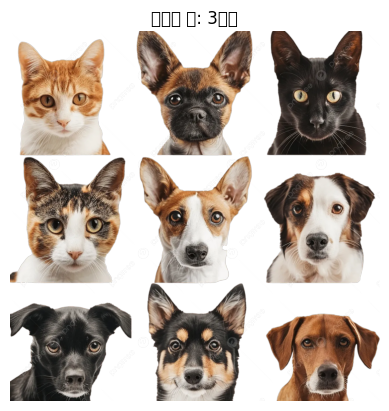


image 1/1 /content/1111111.png: 640x640 3 cats, 4 dogs, 419.9ms
Speed: 5.4ms preprocess, 419.9ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)
1111111.png에서 검출된 고양이 수: 3마리


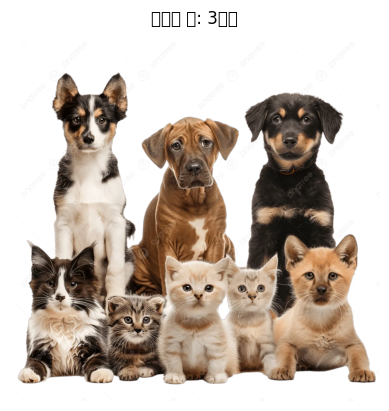

In [14]:
# ✅ 1. YOLOv8 설치 (Ultralytics 제공)
!pip install -q ultralytics

# ✅ 2. 라이브러리 임포트
from ultralytics import YOLO
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
from google.colab import files

# ✅ 3. YOLOv8 모델 로드 (사전 학습된 모델 사용)
model = YOLO('yolov8n.pt')  # 버전에 따라 yolov8s.pt 등으로 변경 가능

# ✅ 4. 이미지 업로드 (직접 2장 업로드)
print("이미지 2장을 업로드하세요:")
uploaded = files.upload()
image_paths = list(uploaded.keys())

# ✅ 5. 고양이 클래스 ID (COCO 기준으로 15번)
CAT_CLASS_ID = 15

# ✅ 6. 각 이미지에서 고양이 개수 검출
for image_path in image_paths:
    results = model(image_path)
    boxes = results[0].boxes

    class_ids = boxes.cls.cpu().numpy()
    cat_count = sum(int(cls_id) == CAT_CLASS_ID for cls_id in class_ids)

    # 결과 출력
    print(f"{image_path}에서 검출된 고양이 수: {cat_count}마리")

    # 시각화
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"고양이 수: {cat_count}마리")
    plt.show()